LAB03 - Tarefa 04

vamos trabalhar com a mesma base de dados utilizada na aula passada, que foi adaptada de um órgão da ONU sobre dados relacionados a diversos países, como qualidade de vida, índice relacionado a percepção de corrupção, entre diversos outros. Para trabalhar nesta tarefa baixar o arquivo DadosWH.csv disponibilizado no Moodle. Vamos agora implementar o algoritmo hierárquico baseado no método de Ward usando as bibliotecas sckit-learn e scipy para agrupar os dados da base de dados disponibilizada, encontrando o melhor número de clusters pelo método de Mojena. Para isso baixar o arquivo Lab03Tarefa04 disponibilizado na nossa Comunidade da disciplina no Moodle.

In [1]:
# Importa as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
import numpy as np
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

In [2]:
dados = pd.read_csv('./DadosWH.csv')
MB = dados.year == 2019
dados2019 = dados[MB]
dados2019

,Name,Continent,year,population,Life_Ladder,Log_GDP_per_capita,Social_support,Healthy_life_expectancy_at_birth,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption,Positive_affect,Negative_affect
9,Afghanistan,Asia,2019,38041754.0,2.375,7.697,0.420,52.4,0.394,-0.108,0.924,0.351,0.502
19,Albania,Europe,2019,2854191.0,4.995,9.544,0.686,69.0,0.777,-0.099,0.914,0.681,0.274
29,Algeria,Africa,2019,43053054.0,4.745,9.337,0.803,66.1,0.385,0.005,0.741,0.585,0.215
39,Argentina,South America,2019,44938712.0,6.086,10.000,0.896,69.0,0.817,-0.211,0.830,0.826,0.319
49,Armenia,Europe,2019,2957731.0,5.488,9.522,0.782,67.2,0.844,-0.172,0.583,0.598,0.430
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1179,Uruguay,South America,2019,3461734.0,6.600,9.979,0.933,69.1,0.903,-0.095,0.599,0.889,0.222
1189,Uzbekistan,Asia,2019,33580650.0,6.154,8.853,0.915,65.4,0.970,0.304,0.511,0.845,0.220
1199,Vietnam,Asia,2019,96462106.0,5.467,8.992,0.848,68.1,0.952,-0.126,0.788,0.751,0.186
1209,Zambia,Africa,2019,17861030.0,3.307,8.155,0.638,55.8,0.811,0.077,0.832,0.743,0.394


In [3]:
# Normaliza os dados das características consideradas (Life_Ladder e Perceptions_of_corruption)
dimensoes = ['Life_Ladder','Perceptions_of_corruption']
Xs = dados2019[dimensoes]
Xs = (Xs - Xs.min())/(Xs.max()-Xs.min())
Xs.index = dados2019['Name']
Xs.head()

,Life_Ladder,Perceptions_of_corruption
Name,,
Afghanistan,0.000000,0.956327
Albania,0.484736,0.945129
Algeria,0.438483,0.751400
Argentina,0.686586,0.851064
Armenia,0.575948,0.574468


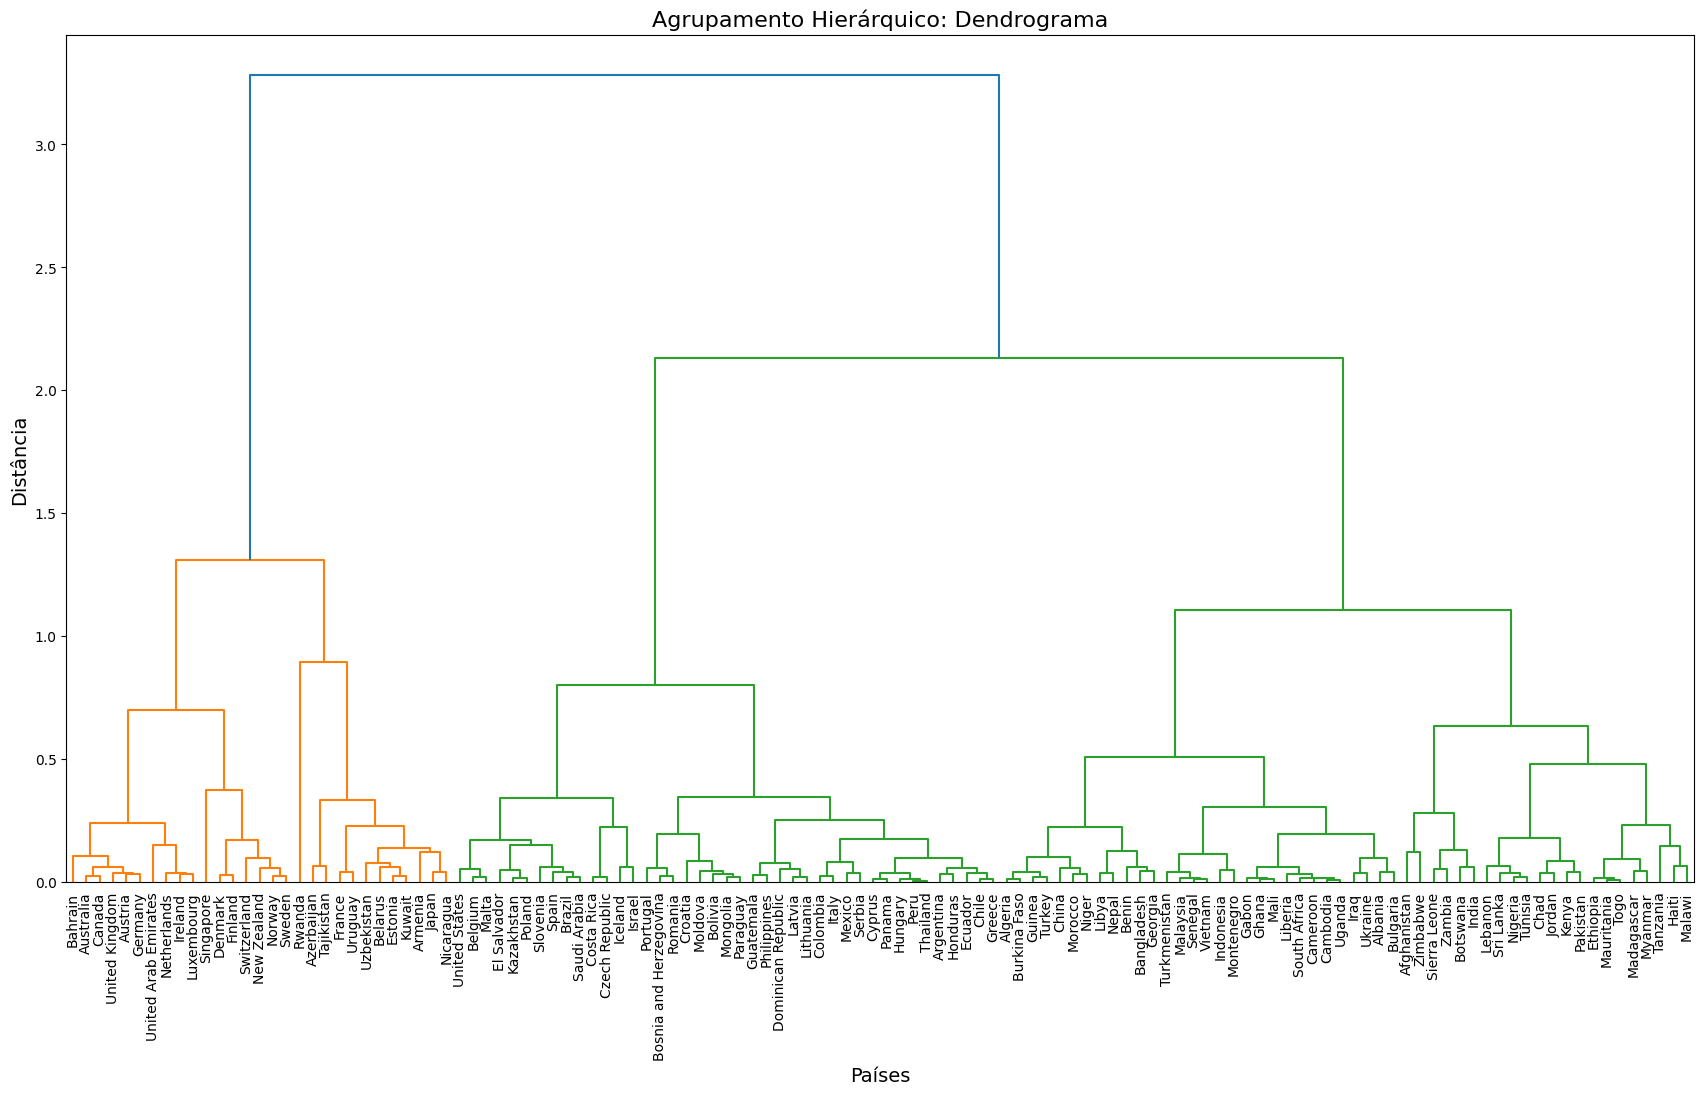

In [4]:
# Plota o dendrograma considerando o método de Ward
plt.figure(figsize=(21,11))
plt.title('Agrupamento Hierárquico: Dendrograma', fontsize=16)
dendrogram_plot = dendrogram(linkage(Xs, method = 'ward'), labels=Xs.index)
plt.xlabel('Países', fontsize=14)
plt.ylabel('Distância', fontsize=14)
plt.tick_params(axis='x', labelsize=10) # Adjust x-axis tick label size
plt.tick_params(axis='y', labelsize=10) # Adjust y-axis tick label size
plt.show()

Qual o número de clusters que vocês considerariam o ideal?

In [5]:
# Aplica o método de Ward para o agrupamento hierárquico
from sklearn.cluster import AgglomerativeClustering
num_clusters = 8
ac = AgglomerativeClustering(n_clusters = num_clusters, linkage='ward')
ac.fit(Xs)
pred=ac.labels_

In [6]:
Xs.index = dados2019.index
Xs['Name'] = dados2019['Name']
Xs.head()

,Life_Ladder,Perceptions_of_corruption,Name
9,0.000000,0.956327,Afghanistan
19,0.484736,0.945129,Albania
29,0.438483,0.751400,Algeria
39,0.686586,0.851064,Argentina
49,0.575948,0.574468,Armenia


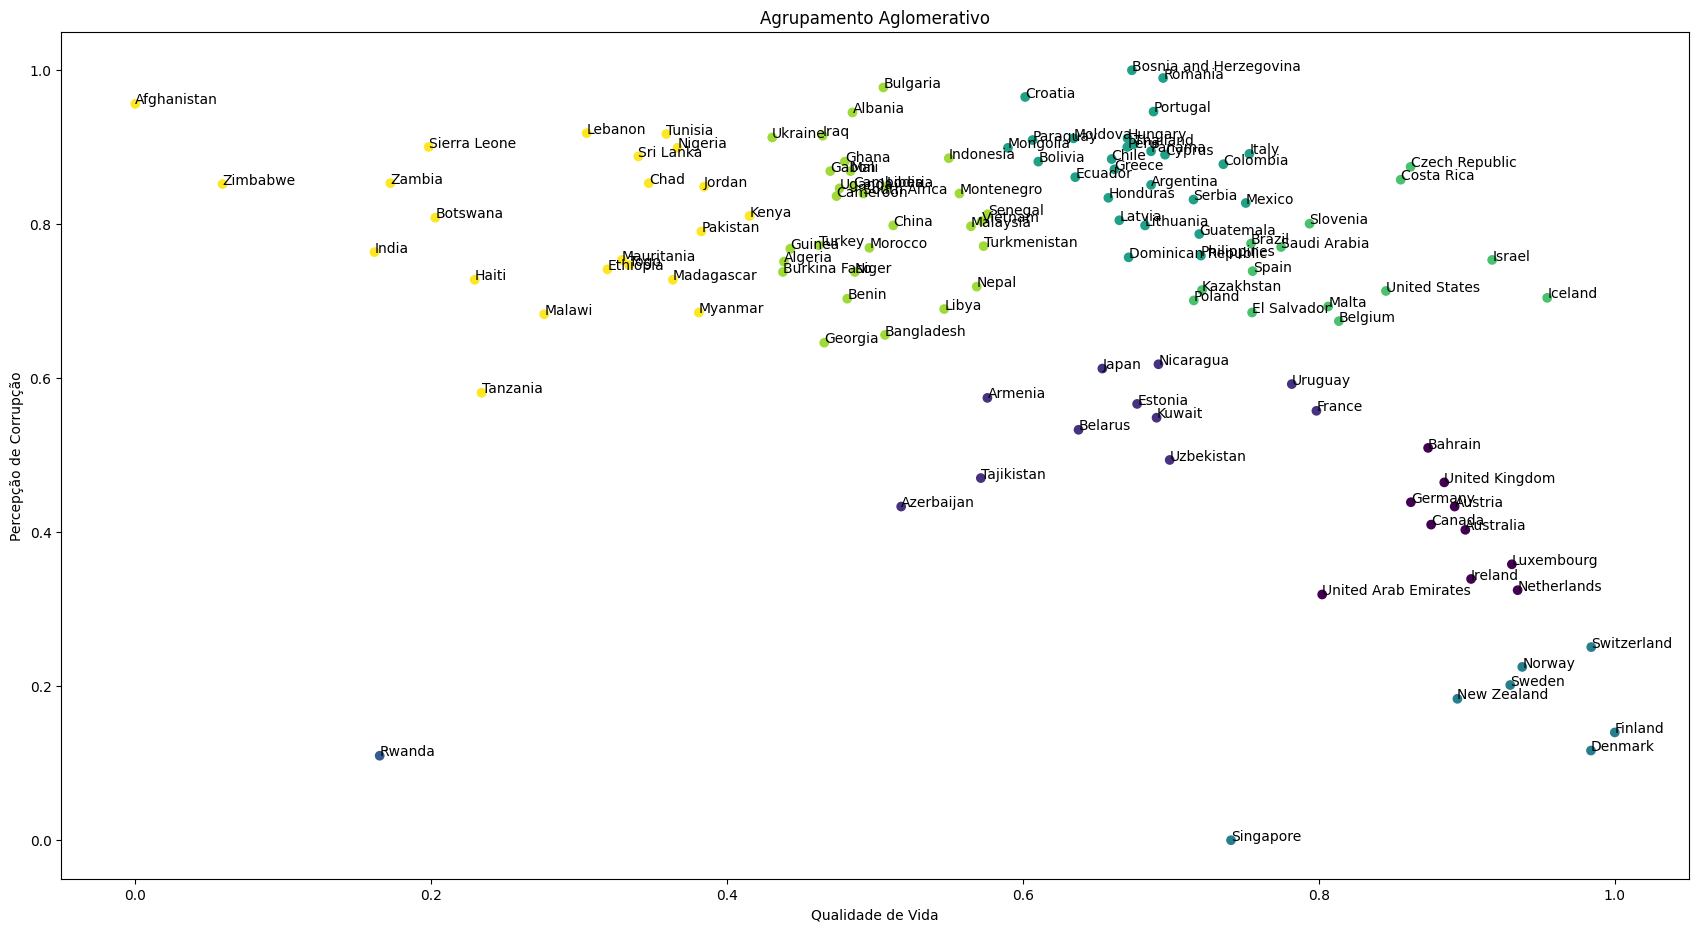

In [7]:
# Plota as amostras com a identificação do cluster
plt.figure(figsize=(21,11))
plt.scatter(Xs.Life_Ladder,Xs.Perceptions_of_corruption,c=pred, marker="o", cmap='viridis_r')
for _, x in Xs.iterrows():
    plt.annotate(x.Name, (x.Life_Ladder, x.Perceptions_of_corruption))
plt.title('Agrupamento Aglomerativo')
plt.xlabel('Qualidade de Vida')
plt.ylabel('Percepção de Corrupção')
plt.show()

In [8]:
# Aplica o método de Mojena para a determinação do número de clusters
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler

# Remove a coluna 'Name' para o agrupamento, se ela existir
Xs_numeric = Xs.drop('Name', axis=1, errors='ignore')

# Aplica o método de Ward para o agrupamento hierárquico
Z = linkage(Xs_numeric, method='ward')
Z

array([[8.80000000e+01, 1.07000000e+02, 5.42159840e-03, 2.00000000e+00],
       [7.10000000e+01, 1.08000000e+02, 8.26338451e-03, 2.00000000e+00],
       [1.90000000e+01, 1.12000000e+02, 9.51794781e-03, 2.00000000e+00],
       [9.50000000e+01, 1.19000000e+02, 9.83988318e-03, 2.00000000e+00],
       [2.80000000e+01, 8.60000000e+01, 1.04449298e-02, 2.00000000e+00],
       [4.70000000e+01, 1.22000000e+02, 1.12175623e-02, 3.00000000e+00],
       [4.10000000e+01, 6.90000000e+01, 1.29162429e-02, 2.00000000e+00],
       [2.00000000e+00, 1.80000000e+01, 1.34582129e-02, 2.00000000e+00],
       [2.30000000e+01, 4.20000000e+01, 1.35646166e-02, 2.00000000e+00],
       [5.70000000e+01, 9.00000000e+01, 1.45390141e-02, 2.00000000e+00],
       [2.00000000e+01, 1.24000000e+02, 1.50449160e-02, 3.00000000e+00],
       [3.80000000e+01, 1.28000000e+02, 1.53170023e-02, 3.00000000e+00],
       [6.80000000e+01, 1.25000000e+02, 1.67720086e-02, 3.00000000e+00],
       [3.50000000e+01, 1.23000000e+02, 1.74876101e

In [9]:
# 3. Implementação do Método de Mojena
def mojena_fator(Z):
    """
    Implementa o método de Mojena para agrupamento hierárquico.
    Z: Matriz linkage do scipy
    k_factor: Valor padrão geralmente entre 1.25 e 1.50
    """
    # Distâncias de fusão (terceira coluna da matriz Z)
    distances = Z[:, 2]

    # Calcular média e desvio padrão das distâncias
    mean_dist = np.mean(distances[0:-1])
    std_dist = np.std(distances[0:-1])

    # Calcular critério de Mojena (k) para cada estágio
    # k_j = (alpha_j - mean) / std
    mojena_k = (distances[-1] - mean_dist) / std_dist

    return mojena_k

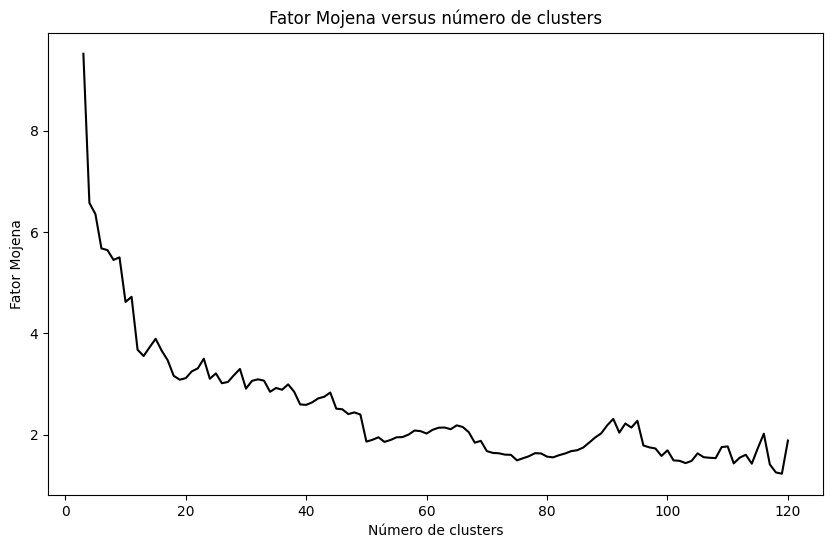

In [10]:
moj_factor = []
N = len(Z)

N_clusters_values = list(range(3, N))
for i in N_clusters_values:
    aux = Z[0:i, :]
    moj_factor.append(mojena_fator(aux))

# Reverse both the moj_factor list and the list of cluster numbers for plotting
moj_factor.reverse()

plt.figure(figsize=(10, 6))
plt.plot(N_clusters_values, moj_factor, color='black')
plt.title('Fator Mojena versus número de clusters')
plt.xlabel('Número de clusters')
plt.ylabel('Fator Mojena')
plt.show()

In [11]:
# Função para encontrar o melhor número de clusters baseado no fator Mojena

def mojena_stopping_rule(Z, k_factor):
    """
    Implementa o método de Mojena para agrupamento hierárquico.
    Z: Matriz linkage do scipy
    k_factor: Valor padrão geralmente entre 1.25 e 1.50
    """
    # Distâncias de fusão (terceira coluna da matriz Z)
    distances = Z[:, 2]

    # Calcular média e desvio padrão das distâncias
    mean_dist = np.mean(distances)
    std_dist = np.std(distances)

    # Calcular critério de Mojena (k) para cada estágio
    # k_j = (alpha_j - mean) / std
    mojena_k = (distances - mean_dist) / std_dist

    # Encontrar o estágio onde a distância é "significativamente" maior
    # O corte é geralmente onde mojena_k > k_factor
    # Pegamos o último estágio que está abaixo do limite para cortar

    stopping_stage = np.argmax(mojena_k > k_factor) - 1

    # Número de clusters = Total de elementos - estágio de parada
    num_clusters = len(distances) - stopping_stage

    return num_clusters, mojena_k

In [12]:
n_clusters, k_values = mojena_stopping_rule(Z, k_factor=1.25)
print(f"Número ideal de clusters (Mojena): {n_clusters}")

Número ideal de clusters (Mojena): 8
